In [1]:

# # Netflix Movies & TV Shows — Exploratory Data Analysis
# > **Dataset:** netflix_titles.csv | Analysing content trends, genres, countries, ratings, and more.

# ## 1. Setup — Imports & Data Loading

In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path


sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})


csv_path = Path.cwd() / "netflix_titles.csv"
df = pd.read_csv(csv_path)

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head(3)

Rows: 8,807  |  Columns: 12


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [3]:


## 2. Data Overview

In [4]:


print("── Column dtypes ──────────────────────")
print(df.dtypes)
print("\n── Missing values ─────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"Missing": missing, "% Missing": missing_pct})[missing > 0])

── Column dtypes ──────────────────────
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

── Missing values ─────────────────────
            Missing  % Missing
director       2634      29.91
cast            825       9.37
country         831       9.44
date_added       10       0.11
rating            4       0.05
duration          3       0.03


In [5]:

df["director"]   = df["director"].fillna("Unknown")
df["cast"]       = df["cast"].fillna("Unknown")
df["country"]    = df["country"].fillna("Unknown")
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"]= df["date_added"].dt.month

df["duration_min"] = (
    df.loc[df["type"] == "Movie", "duration"]
      .str.replace(" min", "", regex=False)
      .astype(float)
)
# extract TV show seasons count
df["seasons"] = (
    df.loc[df["type"] == "TV Show", "duration"]
      .str.replace(" Season.*", "", regex=True)
      .astype(float)
)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (8807, 16)


In [6]:


## 3. Movies vs. TV Shows Distribution

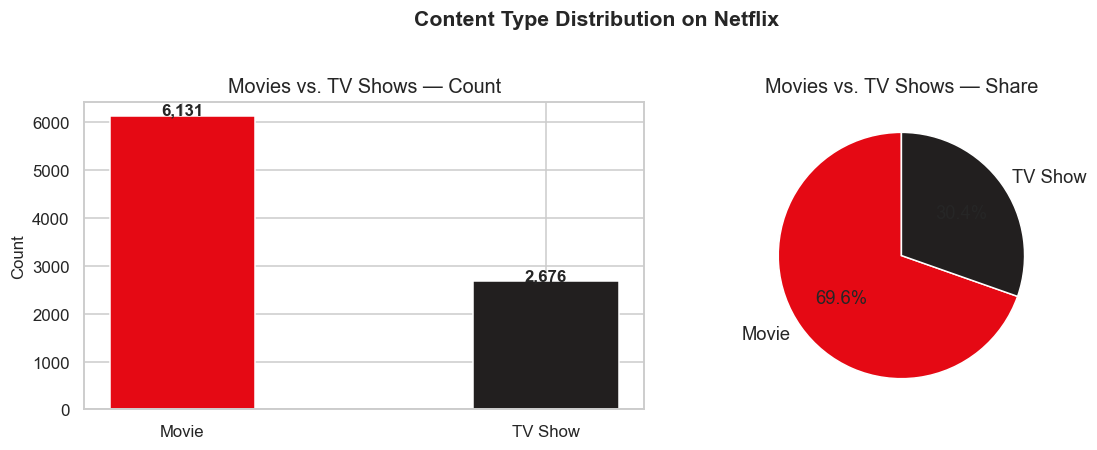

In [7]:


type_counts = df["type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(type_counts.index, type_counts.values, color=["#E50914", "#221F1F"], width=0.4)
axes[0].set_title("Movies vs. TV Shows — Count")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,}", ha="center", fontsize=11, fontweight="bold")

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct="%1.1f%%", colors=["#E50914", "#221F1F"],
            startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Movies vs. TV Shows — Share")

plt.suptitle("Content Type Distribution on Netflix", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [8]:


## 4. Content Added Over the Years

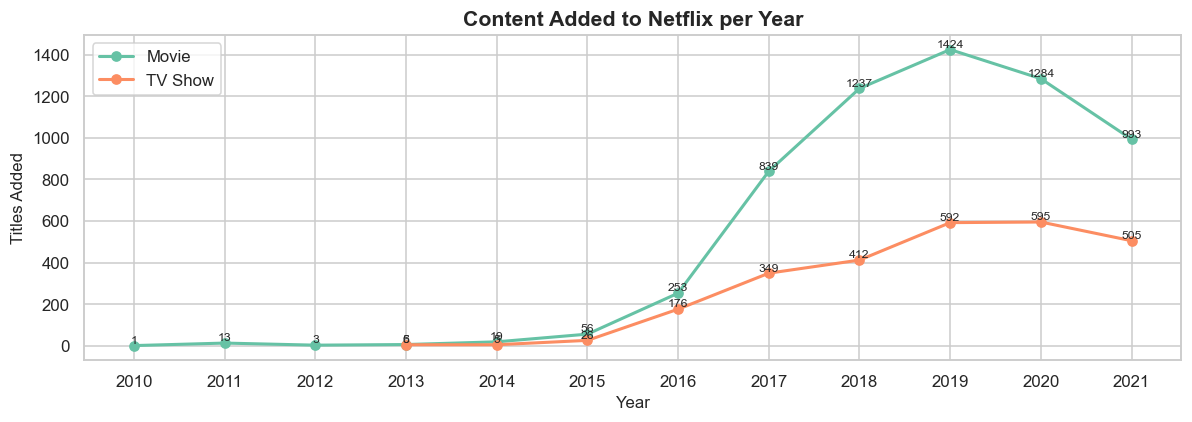

In [9]:


yearly = (
    df.dropna(subset=["year_added"])
      .groupby(["year_added", "type"])
      .size()
      .reset_index(name="count")
)
# keep sensible range
yearly = yearly[yearly["year_added"] >= 2010]

fig, ax = plt.subplots(figsize=(11, 4))
for content_type, grp in yearly.groupby("type"):
    ax.plot(grp["year_added"], grp["count"], marker="o", label=content_type, linewidth=2)
    for x, y in zip(grp["year_added"], grp["count"]):
        ax.text(x, y + 10, str(int(y)), ha="center", fontsize=8)

ax.set_title("Content Added to Netflix per Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Titles Added")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

In [10]:


## 5. Top 10 Countries Producing Content

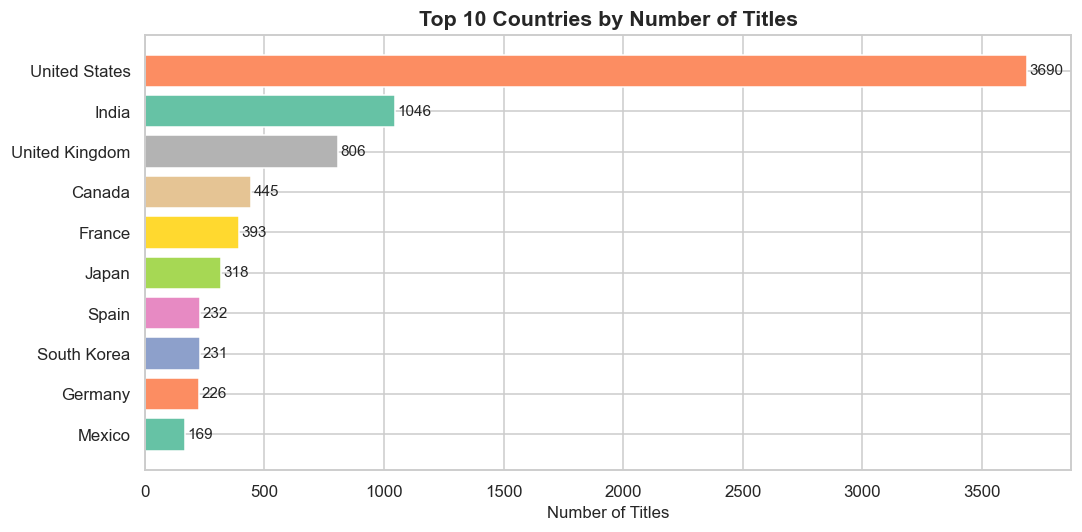

In [11]:


# split multi-country entries, take first listed country
country_series = (
    df[df["country"] != "Unknown"]["country"]
      .str.split(",")
      .explode()
      .str.strip()
)
top_countries = country_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=sns.color_palette("Set2", 10))
ax.set_title("Top 10 Countries by Number of Titles", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Titles")
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)
plt.tight_layout()
plt.show()

In [12]:


## 6. Content Ratings Distribution

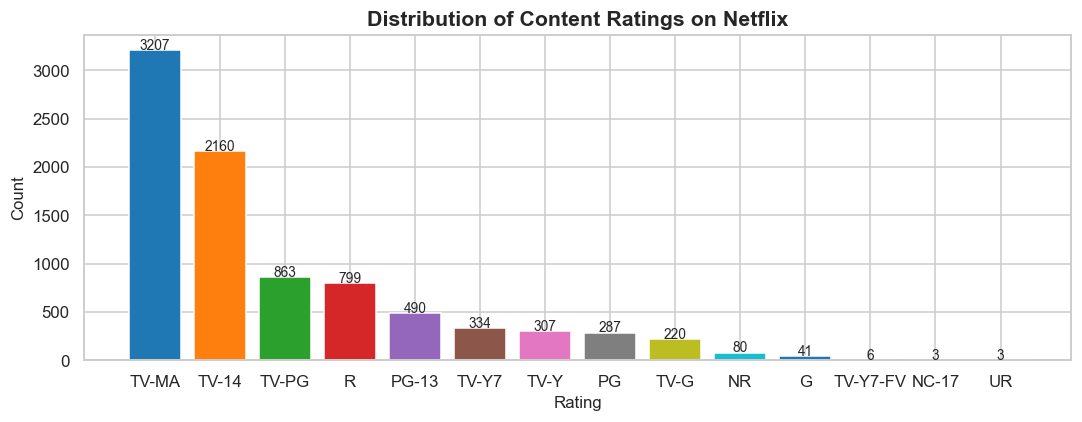

In [13]:


rating_counts = df["rating"].value_counts().dropna()
# drop rows that are actually durations misplaced in rating column
valid_ratings = rating_counts[~rating_counts.index.str.contains("min|Season", na=False)]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(valid_ratings.index, valid_ratings.values,
              color=sns.color_palette("tab10", len(valid_ratings)))
ax.set_title("Distribution of Content Ratings on Netflix", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [14]:


## 7. Top 10 Genres

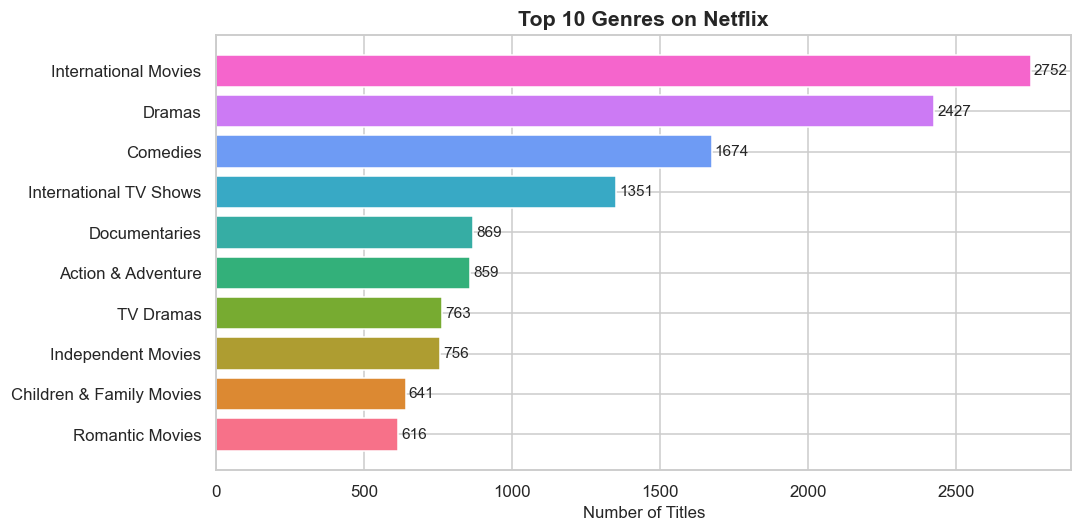

In [15]:


genre_series = (
    df["listed_in"].dropna()
      .str.split(",")
      .explode()
      .str.strip()
)
top_genres = genre_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=sns.color_palette("husl", 10))
ax.set_title("Top 10 Genres on Netflix", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Titles")
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)
plt.tight_layout()
plt.show()

In [16]:


## 8. Top 10 Directors

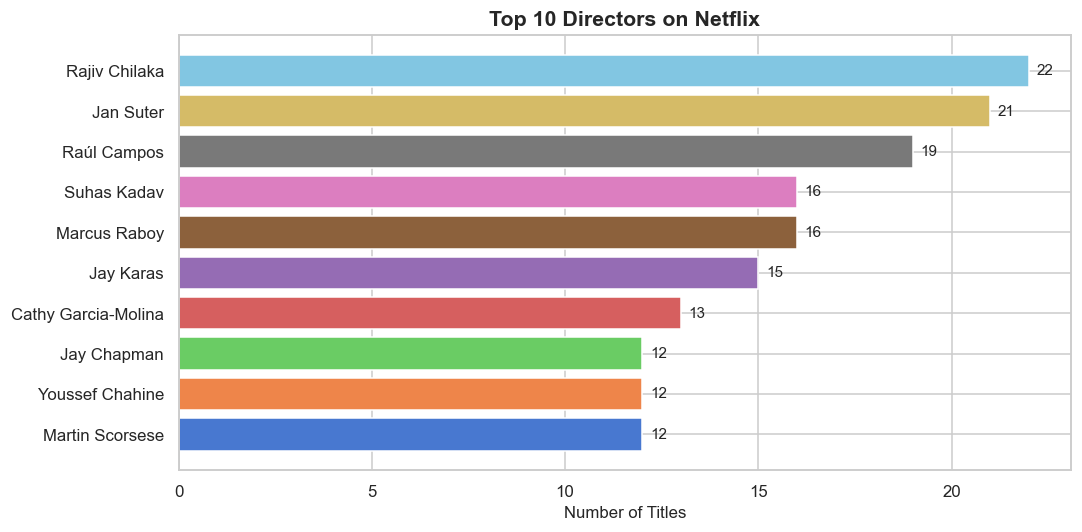

In [17]:


director_series = (
    df[df["director"] != "Unknown"]["director"]
      .str.split(",")
      .explode()
      .str.strip()
)
top_directors = director_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_directors.index[::-1], top_directors.values[::-1],
               color=sns.color_palette("muted", 10))
ax.set_title("Top 10 Directors on Netflix", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Titles")
for bar, val in zip(bars, top_directors.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)
plt.tight_layout()
plt.show()

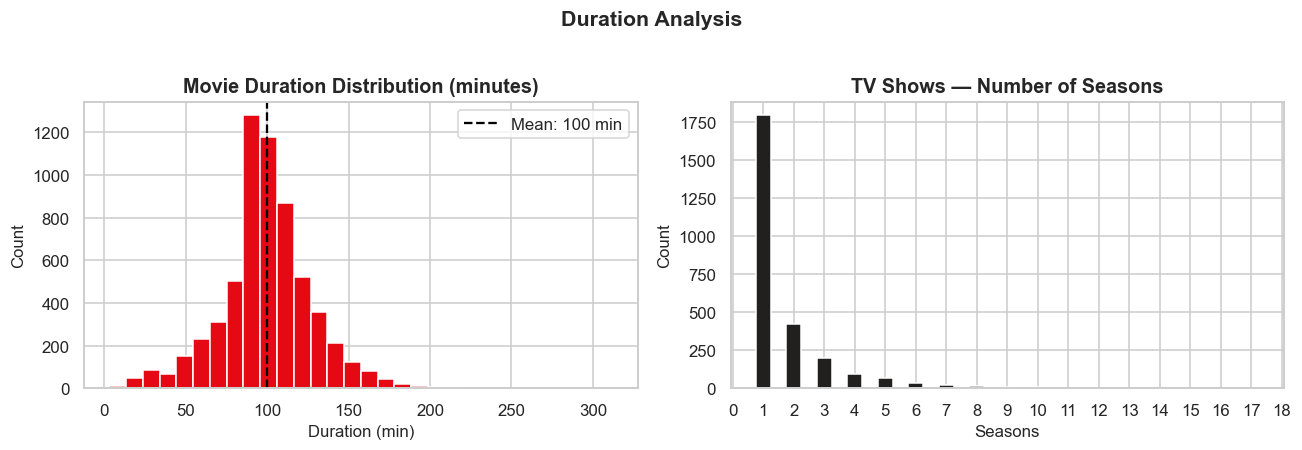


── Advanced Feature Engineering & Data Imputation ─────────────────────

--- Time to Netflix ---
count    8797.000000
mean        4.688417
std         8.786998
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: time_to_netflix, dtype: float64

--- Target Audience Distribution ---
target_audience
Adults     4092
Teens      2650
Kids       1195
Unknown     870
Name: count, dtype: int64

--- Smart Imputation complete ---

--- Top 10 Actors Globally ---
cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

--- Top Genres after Exploding ---
genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventur

In [18]:


## 9. Movie Duration & TV Show Seasons
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Movie duration histogram
movie_dur = df.dropna(subset=["duration_min"])
axes[0].hist(movie_dur["duration_min"], bins=30, color="#E50914", edgecolor="white")
axes[0].set_title("Movie Duration Distribution (minutes)", fontweight="bold")
axes[0].set_xlabel("Duration (min)")
axes[0].set_ylabel("Count")
axes[0].axvline(movie_dur["duration_min"].mean(), color="black",
                linestyle="--", label=f"Mean: {movie_dur['duration_min'].mean():.0f} min")
axes[0].legend()

# TV Show seasons bar chart
seasons_counts = df.dropna(subset=["seasons"])["seasons"].value_counts().sort_index()
axes[1].bar(seasons_counts.index.astype(int), seasons_counts.values, color="#221F1F", width=0.5)
axes[1].set_title("TV Shows — Number of Seasons", fontweight="bold")
axes[1].set_xlabel("Seasons")
axes[1].set_ylabel("Count")
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.suptitle("Duration Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# ## Key Takeaways
# - **Movies dominate** the catalogue (~70 % of titles).
# - Content additions **peaked around 2019** before declining.
# - **United States** leads in content production by a large margin.
# - **TV-MA** and **TV-14** are the most common ratings.
# - The most popular genres are **International Movies, Dramas, and Comedies**.
# - Average movie runtime is approximately **~100 minutes**.
# - Most TV shows have only **1 season**.

# ## 10. Advanced Feature Engineering & Data Imputation
print("\n── Advanced Feature Engineering & Data Imputation ─────────────────────")

# 1. Time to Netflix (Gap between release and added to Netflix)
df['time_to_netflix'] = df['year_added'] - df['release_year']
print("\n--- Time to Netflix ---")
print(df['time_to_netflix'].describe())

# 2. Target Audience Categorization
def categorize_audience(rating):
    kids = ['TV-Y', 'TV-Y7', 'G', 'TV-G', 'PG', 'TV-Y7-FV']
    teens = ['TV-14', 'PG-13']
    adults = ['TV-MA', 'R', 'NC-17', 'UR', 'NR']
    if rating in kids:
        return 'Kids'
    elif rating in teens:
        return 'Teens'
    elif rating in adults:
        return 'Adults'
    else:
        return 'Unknown'

df['target_audience'] = df['rating'].apply(categorize_audience)
print("\n--- Target Audience Distribution ---")
print(df['target_audience'].value_counts())

# 3. Smart Missing Data Imputation: Impute Country by Director
# First, revert the 'Unknown' fill for country temporarily to apply logic
df['country'] = df['country'].replace('Unknown', np.nan)

# Create a mapping of Director -> Most Frequent Country
director_country_map = df.dropna(subset=['director', 'country']).groupby('director')['country'].agg(lambda x: pd.Series.mode(x)[0]).to_dict()

# Apply the mapping
df.loc[df['country'].isnull() & df['director'].notnull(), 'country'] = df['director'].map(director_country_map)

# Fill remaining with 'Unknown'
df['country'] = df['country'].fillna('Unknown')
print("\n--- Smart Imputation complete ---")

## 11. Exploding Multi-Value Columns for Analysis

# 1. Actor/Director Activity (Exploding Cast)
# Revert 'Unknown' cast
cast_valid = df[df['cast'] != 'Unknown']
cast_exploded = cast_valid.assign(cast=cast_valid['cast'].str.split(', ')).explode('cast')

print("\n--- Top 10 Actors Globally ---")
print(cast_exploded['cast'].value_counts().head(10))

# 2. Genre Co-occurrence
listed_in_exploded = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
print("\n--- Top Genres after Exploding ---")
print(listed_in_exploded['genre'].value_counts().head(10))

print("\nFeature Engineering and Data Imputation added successfully!")